# Connectivity Plots (Objective 4)

Reads the raster/vector outputs of the R Objective 4 pipeline (`scripts/r/06_prepare_connectivity_inputs.R`
through `11_consensus_priority_mapping.R`) from `outputs/rasters/connectivity/`, `outputs/vectors/`,
and `outputs/tables/`. Pure pandas/geopandas/matplotlib post-processing -- no R or Earth Engine calls.


In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

import config


In [2]:
sns.set_theme(style="whitegrid")
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SITE_ORDER = [s["site_id"] for s in config.SITES]
SITE_LABELS = {s["site_id"]: s["site_name"] for s in config.SITES}

site_boundaries = gpd.GeoDataFrame(
    pd.concat(
        [gpd.read_file(p).to_crs(config.PROJECT_CRS) for p in config.AOI_PATHS.values()],
        ignore_index=True,
    )
)


## Plots 1-2: Pressure context maps (moved from `landscape_metrics.ipynb`)

Objective 1's Dynamic World conversion-pressure classification
(`pressure_composition_by_period.png` in `historical_change_plots.ipynb`) uses thresholds that
were never calibrated against ground truth (unlike `DW_HABITAT_THRESHOLDS`'s documented 3-round
calibration) -- treat that chart as preliminary. `settlement_pressure_30m.tif`/
`road_pressure_30m.tif` below are stronger, complementary evidence for the same "where is
pressure coming from" question: built from real GIS vector data (settlement points, OSM road
network), not an inferred spectral proxy. `landscape_metrics.ipynb`'s own Plots 7-8
(`local_edge_density_change_*`/`local_patch_density_change_*`, Objective 3 -- raw observed
baseline-to-current fragmentation change) round out that same evidence base.


In [3]:
def plot_raster_map(raster_path, title, filename, cmap, cbar_label, diverging=False, vmin=None, vmax=None):
    """Static map of one single-band continuous raster, with site boundaries for context.

    diverging=True centers the colormap at 0 (TwoSlopeNorm) and, if vmin/vmax aren't given,
    picks a symmetric range from the 98th percentile of |value| -- robust to a few extreme
    per-window outliers rather than letting them wash out the rest of the map.
    """
    with rasterio.open(raster_path) as src:
        arr = src.read(1, masked=True).filled(np.nan)
        left, bottom, right, top = src.bounds

    norm = None
    if diverging:
        if vmax is None:
            vmax = np.nanpercentile(np.abs(arr), 98)
            vmin = -vmax
        norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
        vmin = vmax = None  # norm supersedes vmin/vmax in imshow

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(arr, extent=(left, right, bottom, top), origin="upper", cmap=cmap, norm=norm, vmin=vmin, vmax=vmax)
    site_boundaries.boundary.plot(ax=ax, color="#484848", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)", fontsize=10.5)
    ax.set_ylabel("Northing (m)", fontsize=10.5)

    # Full meter notation on both axes -- matplotlib defaults to a scientific offset on the y
    # axis once values get this large; disable it so y matches x's plain notation.
    ax.ticklabel_format(axis="both", style="plain", useOffset=False)
    # Slightly fewer gridlines than the default auto locator (was ~7 per axis at ~2000m spacing).
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis="both", labelsize=7.0)
    ax.grid(True, alpha=0.6)  # same grid color as the notebook's whitegrid theme, just lighter

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label, fontsize=10.5)
    cbar.ax.tick_params(labelsize=9.5)

    fig.tight_layout()
    fig.savefig(config.PLOTS_DIR / filename, dpi=200, bbox_inches="tight")


### Plot 1: Settlement pressure (Objective 4)

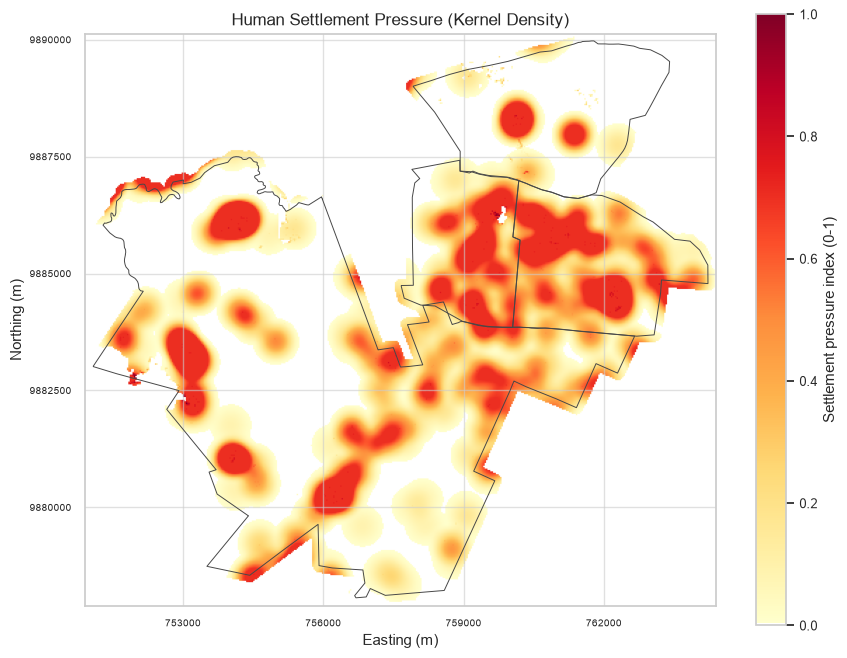

In [10]:
# Get the original YlOrRd colormap
original_cmap = plt.cm.YlOrRd
colors = ['white'] + [original_cmap(i) for i in range(original_cmap.N)]
cmap_white_zero = LinearSegmentedColormap.from_list('YlOrRd_white_zero',  colors, N=original_cmap.N) # no data (0) is white, not the lightest yellow

plot_raster_map(
    config.CONNECTIVITY_RASTER_DIR / "settlement_pressure_30m.tif",
    "Human Settlement Pressure (Kernel Density)",
    "connectivity_settlement_pressure.png",
    cmap=cmap_white_zero,
    cbar_label="Settlement pressure index (0-1)",
    vmin=0,
    vmax=1,
)

### Plot 2: Road pressure (Objective 4)

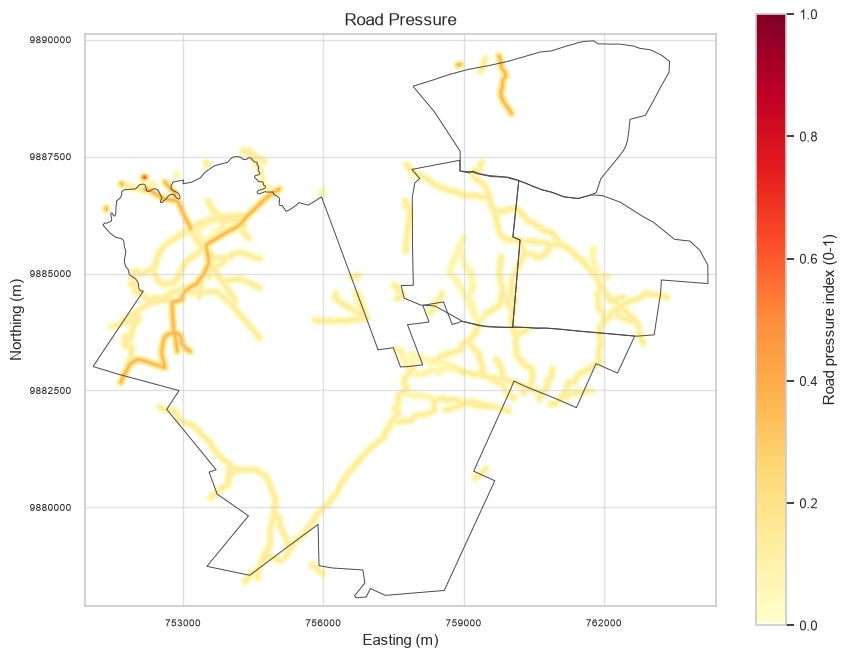

In [5]:
# Get the original YlOrRd colormap
original_cmap = plt.cm.YlOrRd
colors = ['white'] + [original_cmap(i) for i in range(original_cmap.N)]
cmap_white_zero = LinearSegmentedColormap.from_list('YlOrRd_white_zero',  colors, N=original_cmap.N) # no data (0) is white, not the lightest yellow

plot_raster_map(
    config.CONNECTIVITY_RASTER_DIR / "road_pressure_30m.tif",
    "Road Pressure",
    "connectivity_road_pressure.png",
    cmap=cmap_white_zero,
    cbar_label="Road pressure index (0-1)",
    vmin=0,
    vmax=1,
)

## Plots 3-5: Consensus priority mapping (`11_consensus_priority_mapping.R`)

Each of `connectivity_barrier_candidates.gpkg`, `connectivity_bottleneck_candidates.gpkg`,
`connectivity_protection_priority.gpkg`, and `connectivity_restoration_priority.gpkg` is a single
dissolved (multi)polygon -- the "1" cells of a binary threshold-rule mask (see that script's own
percentile-threshold constants in `00_config.R`), not a continuous surface. Plotted here as a
flat fill color with the same site-boundary style as Plots 1-2, not a raster.


In [6]:
def plot_binary_mask_pair(specs, filename):
    """1x2 figure of two single dissolved binary-mask polygon layers, one panel each, with a
    fill color + site boundaries for context (same #484848 style as Plots 1-2). One shared
    legend below both panels rather than repeating it per axis.

    specs: list of (gpkg_path, title, color, legend_label) tuples, length 2.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, (path, title, color, label) in zip(axes, specs):
        gdf = gpd.read_file(path)
        gdf.plot(ax=ax, color=color, edgecolor=color, alpha=0.6, label=label)
        site_boundaries.boundary.plot(ax=ax, color="#484848", linewidth=0.7)
        ax.set_title(title)
        ax.set_xlabel("Easting (m)", fontsize=10.5)
        ax.set_ylabel("Northing (m)", fontsize=10.5)
        ax.ticklabel_format(axis="both", style="plain", useOffset=False)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis="both", labelsize=7.0)
        ax.grid(True, alpha=0.6)

    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
    fig.legend(handles, labels, loc="lower center", ncol=len(handles), bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(config.PLOTS_DIR / filename, dpi=200, bbox_inches="tight")


### Plot 3: Barrier & bottleneck candidates

Both are threshold-rule masks combining Omniscape current flow with resistance (see
`11_consensus_priority_mapping.R`'s own docs): a **barrier candidate** is high resistance + high
flow-demand + low source quality (current wants to move through here but can't) -- the most
threat-like of the four masks in Plots 3-5. A **bottleneck (high confidence)** is high current +
high resistance, flagged by >=2 of the 6 Omniscape scenarios -- a squeeze point rather than an
outright blockage.


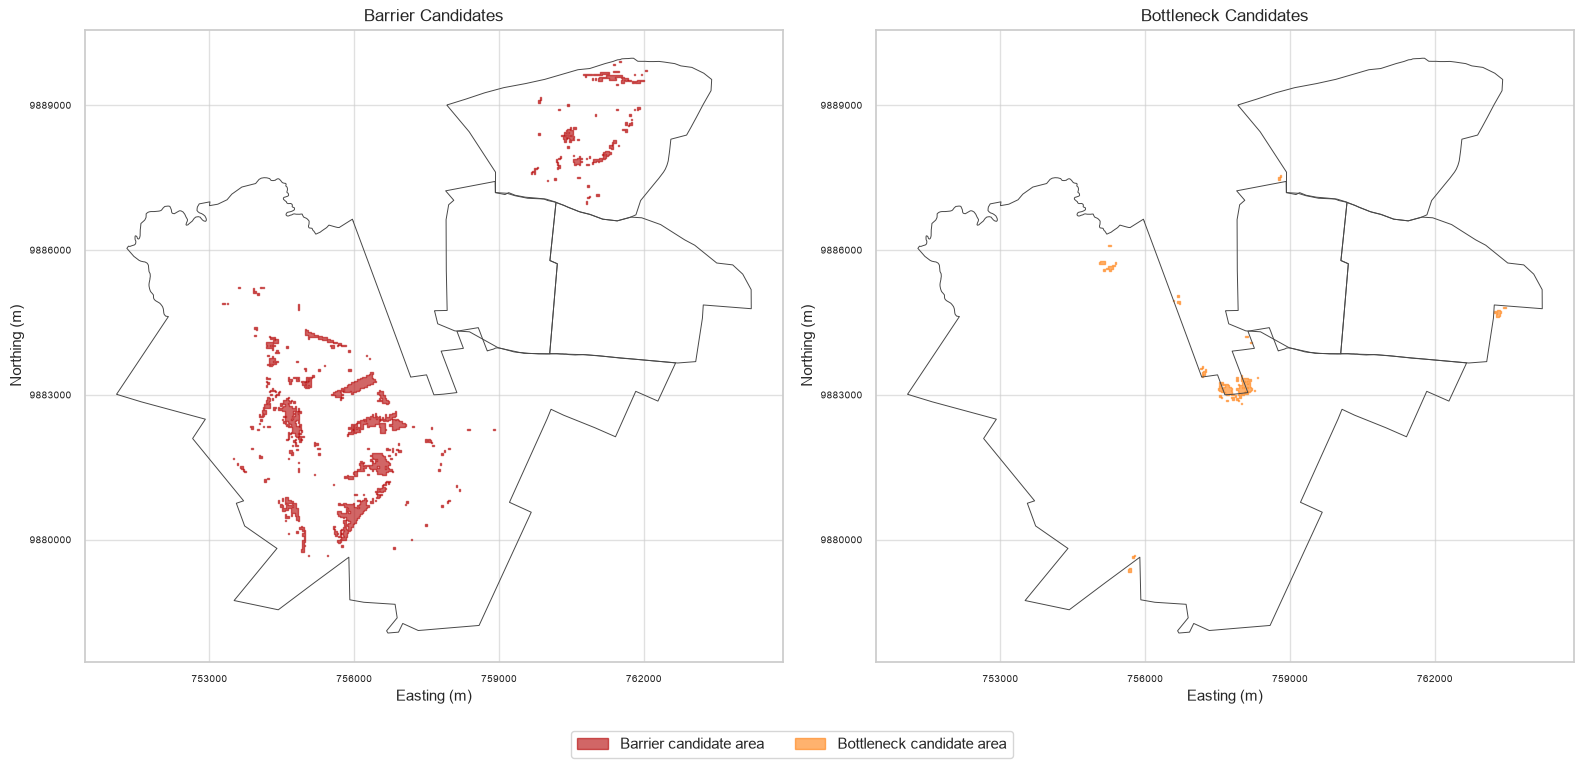

In [11]:
plot_binary_mask_pair(
    [
        (
            config.VECTORS_DIR / "connectivity_barrier_candidates.gpkg",
            "Barrier Candidates",
            "#b30000",
            "Barrier candidate area",
        ),
        (
            config.VECTORS_DIR / "connectivity_bottleneck_candidates.gpkg",
            "Bottleneck Candidates",
            "#ff7f0e",
            "Bottleneck candidate area",
        ),
    ],
    "connectivity_barrier_bottleneck_candidates.png",
)

### Plot 4: Habitat patch importance (current)

`connectivity_habitat_patches_current.gpkg`'s own `tier` field is already a discretized
importance category (tier1-3/untiered); this plot instead uses the underlying continuous
`protection_importance_score` (joined in from `connectivity_patch_importance_scores_current.csv`
by `patch_id` -- a weighted blend of connectivity, source strength, core area, stepping-stone
value, and inverse human pressure; see `PROTECTION_IMPORTANCE_WEIGHTS` in `00_config.R`), binned
into 5 Natural-Breaks (Jenks) classes -- true graduated symbology, not just a flat category fill.
`restoration_importance_score` is the other importance score this table carries (current/flow +
resistance/degradation + corridor proximity weighted instead) -- a reasonable alternative view,
not charted here.


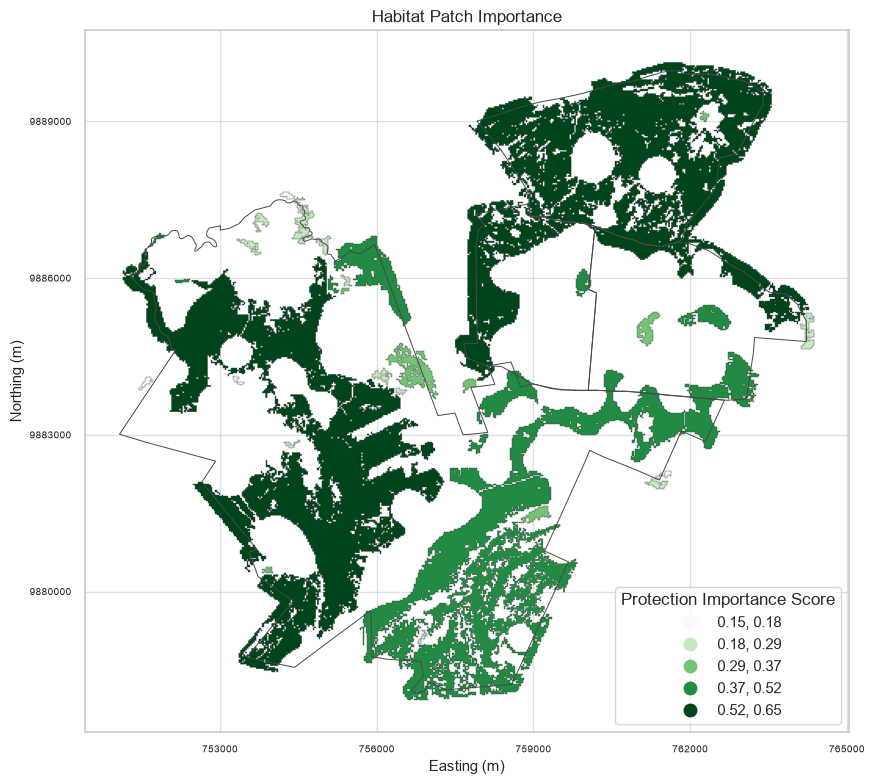

In [13]:
patches = gpd.read_file(config.VECTORS_DIR / "connectivity_habitat_patches_current.gpkg")
patch_scores = pd.read_csv(config.TABLES_DIR / "connectivity_patch_importance_scores_current.csv")[
    ["patch_id", "protection_importance_score"]
]
patches = patches.merge(patch_scores, on="patch_id", how="left")

fig, ax = plt.subplots(figsize=(9, 8))
patches.plot(
    column="protection_importance_score",
    scheme="NaturalBreaks",
    k=5,
    cmap="Greens",
    legend=True,
    legend_kwds={"title": "Protection Importance Score", "loc": "lower right", "fmt": "{:.2f}"},
    edgecolor="#484848",
    linewidth=0.3,
    ax=ax,
)
site_boundaries.boundary.plot(ax=ax, color="#484848", linewidth=0.7)
ax.set_title("Habitat Patch Importance")
ax.set_xlabel("Easting (m)", fontsize=10.5)
ax.set_ylabel("Northing (m)", fontsize=10.5)
ax.ticklabel_format(axis="both", style="plain", useOffset=False)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(axis="both", labelsize=7.0)
ax.grid(True, alpha=0.6)
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "connectivity_patch_importance.png", dpi=200, bbox_inches="tight")

### Plot 5: Protection & restoration priority

Both threshold-rule masks again (see Plot 3): **protection priority** is high source quality +
high current + low resistance (already-good habitat, well connected -- protect it); **restoration
priority** is high flow-demand + high resistance + not already built over (movement wants to
happen here but can't yet -- a restoration candidate).


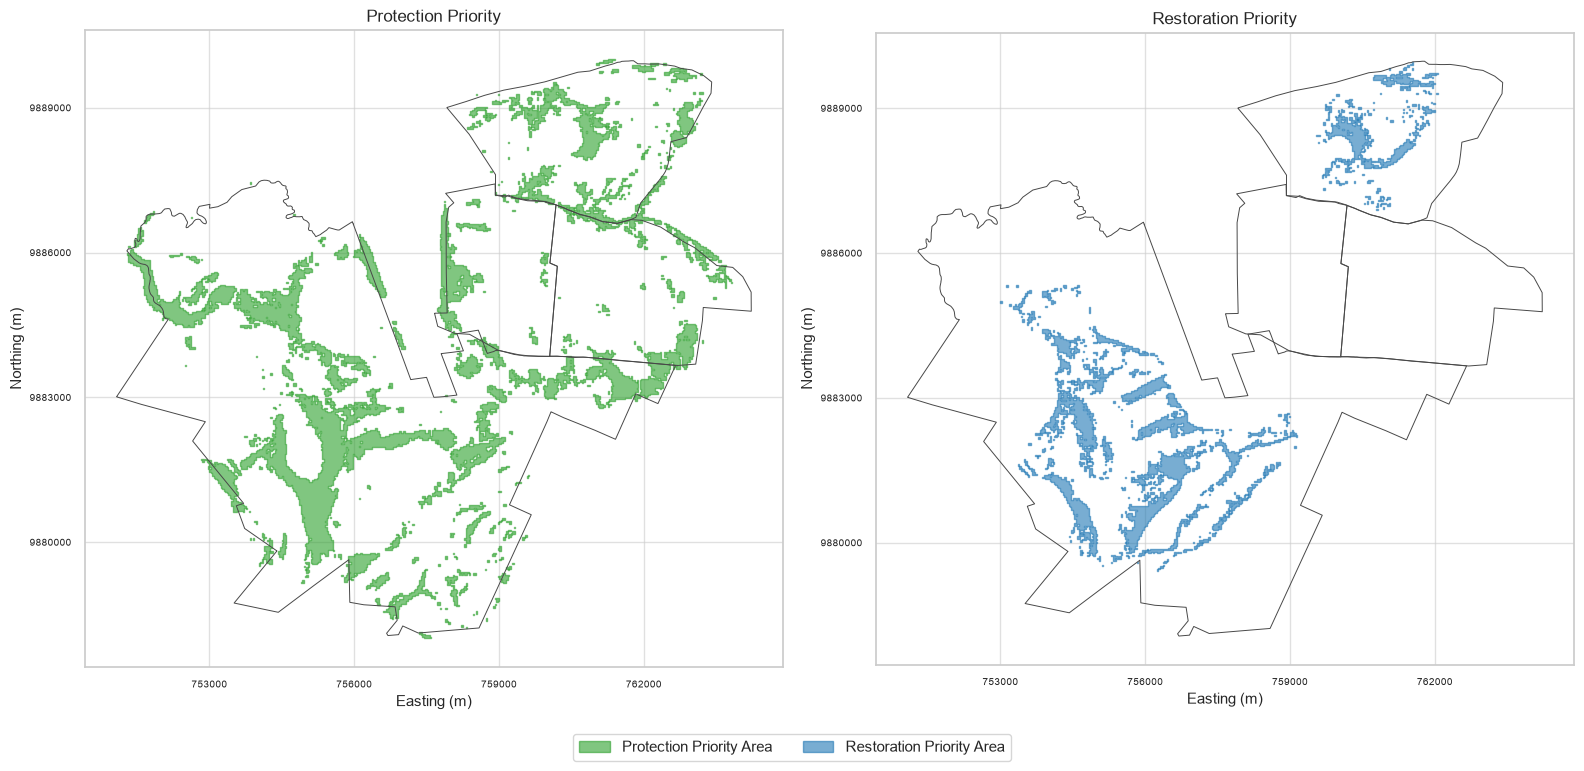

In [14]:
plot_binary_mask_pair(
    [
        (
            config.VECTORS_DIR / "connectivity_protection_priority.gpkg",
            "Protection Priority",
            "#2ca02c",
            "Protection Priority Area",
        ),
        (
            config.VECTORS_DIR / "connectivity_restoration_priority.gpkg",
            "Restoration Priority",
            "#1f77b4",
            "Restoration Priority Area",
        ),
    ],
    "connectivity_protection_restoration_priority.png",
)